## 1. Import Learners
Test that all learner modules can be imported successfully.

In [1]:
import numpy as np
from dml.learners.lasso import LassoLearner
from dml.learners.elastic_net import ElasticNetLearner
from dml.learners.random_forest import RandomForestLearner

print("All imports successful!")

All imports successful!


## 2. Basic Fit & Predict Test
Verify that all three learners can fit on synthetic data and return predictions of the correct shape.

In [2]:
np.random.seed(42)
n, p = 100, 5
X = np.random.randn(n, p)
y = X @ np.ones(p) + np.random.randn(n)

learners = {
    "Lasso": LassoLearner(),
    "ElasticNet": ElasticNetLearner(),
    "RandomForest": RandomForestLearner()
}

for name, learner in learners.items():
    learner.fit(X, y)
    y_pred = learner.predict(X)
    print(f"{name}: output shape = {y_pred.shape}, first 3 predictions = {y_pred[:3].round(2)}")

Lasso: output shape = (100,), first 3 predictions = [ 2.12  1.96 -4.35]
ElasticNet: output shape = (100,), first 3 predictions = [ 2.12  1.97 -4.36]
RandomForest: output shape = (100,), first 3 predictions = [ 2.32  2.96 -4.64]


## 3. CausalForest Learner Test
Verify that CausalForestLearner can be imported and produces correct output shape.

In [3]:
from dml.learners.causal_forest import CausalForestLearner

cf_learner = CausalForestLearner()
cf_learner.fit(X, y)
y_pred = cf_learner.predict(X)
print(f"CausalForest: output shape = {y_pred.shape}, first 3 predictions = {y_pred[:3].round(2)}")

CausalForest: output shape = (100,), first 3 predictions = [ 0.13  0.87 -1.05]


## 4. Cross-fitting Test
Verify that cross-fitting produces out-of-sample predictions for all observations.

In [4]:
from dml.utils.cross_fitting import cross_fit

learner = LassoLearner()
y_pred_cf = cross_fit(learner, X, y, n_splits=5, random_state=66)

print(f"Input shape: {y.shape}")
print(f"Output shape: {y_pred_cf.shape}")
print(f"Residuals (first 5): {(y - y_pred_cf)[:5].round(3)}")

Input shape: (100,)
Output shape: (100,)
Residuals (first 5): [ 0.991  2.292 -1.494  0.698 -0.425]


## 5. Aggregated DML + Honest Cross-fitting Test
Verify that cross_fit_aggregated and cross_fit_honest work correctly.

In [5]:
from dml.utils.cross_fitting import cross_fit_aggregated, cross_fit_honest

# test aggregated DML
np.random.seed(66)
n, p = 200, 10
X = np.random.randn(n, p)
y = X @ np.ones(p) + np.random.randn(n)

learner = LassoLearner()

# standard cross-fitting
y_pred_std = cross_fit(learner, X, y, random_state=66)

# aggregated cross-fitting (S=10)
y_pred_agg = cross_fit_aggregated(learner, X, y, n_rep=10, random_state=66)

# honest cross-fitting
y_pred_hon = cross_fit_honest(LassoLearner(), LassoLearner(), X, y, random_state=66)

print(f"Standard:   shape={y_pred_std.shape}, MSE={np.mean((y-y_pred_std)**2):.4f}")
print(f"Aggregated: shape={y_pred_agg.shape}, MSE={np.mean((y-y_pred_agg)**2):.4f}")
print(f"Honest:     shape={y_pred_hon.shape}, MSE={np.mean((y-y_pred_hon)**2):.4f}")

Standard:   shape=(200,), MSE=1.4226
Aggregated: shape=(200,), MSE=1.4316
Honest:     shape=(200,), MSE=3.7882


## 6. PLR Verification
Verify that PLR correctly estimates theta on synthetic data where true theta_0 = 1.

In [6]:
from dml.models.plr import PLR

# 造合成数据，真实 theta_0 = 1
np.random.seed(66)
n, p = 500, 20
X = np.random.randn(n, p)
theta_0 = 1.0
D = X @ np.random.randn(p) + np.random.randn(n)
Y = theta_0 * D + X @ np.random.randn(p) + np.random.randn(n)

# 用 Lasso 跑 PLR
plr = PLR(learner=LassoLearner(), n_splits=5, random_state=66)
plr.fit(Y, D, X)
results = plr.predict()

print(f"True theta_0:  {theta_0}")
print(f"Estimated theta: {results['theta']:.4f}")
print(f"95% CI: ({results['ci_lower']:.4f}, {results['ci_upper']:.4f})")
print(f"CI contains true theta: {results['ci_lower'] < theta_0 < results['ci_upper']}")

True theta_0:  1.0
Estimated theta: 0.9545
95% CI: (0.8652, 1.0438)
CI contains true theta: True


## 7. IRM Verification
Verify that IRM correctly estimates ATE on synthetic binary treatment data.

In [7]:
from dml.models.irm import IRM
from dml.learners.lasso import LassoLearner
import numpy as np

# 造合成数据，真实 theta_0 = 1.0，binary treatment
np.random.seed(66)
n = 500
X = np.random.randn(n, 5)
D = (np.random.randn(n) > 0).astype(float)
g0_true = np.sin(X[:, 0])
g1_true = np.sin(X[:, 0]) + 1.0
Y = D * 1.0 + g0_true + np.random.randn(n)
theta_0 = 1.0

# 用 Lasso 跑 IRM
irm = IRM(learner=LassoLearner(), n_splits=5, random_state=66)
irm.fit(Y, D, X)
results = irm.predict()

print(f"True theta_0:    {theta_0}")
print(f"Estimated theta: {results['theta']:.4f}")
print(f"95% CI: ({results['ci_lower']:.4f}, {results['ci_upper']:.4f})")
print(f"CI contains true theta: {results['ci_lower'] < theta_0 < results['ci_upper']}")

True theta_0:    1.0
Estimated theta: 1.1493
95% CI: (0.9712, 1.3274)
CI contains true theta: True


## 8. Clean Import Test
Verify that the package-level imports work correctly.

In [8]:
from dml import LassoLearner, ElasticNetLearner, RandomForestLearner, CausalForestLearner
from dml import PLR, IRM

print("Package-level imports successful!")

Package-level imports successful!


## 9. Neural Network Learner Test
Verify that NeuralNetLearner works as a drop-in replacement for other learners.

In [9]:
from dml.learners.neural_net import NeuralNetLearner

np.random.seed(66)
n, p = 200, 10
X = np.random.randn(n, p)
y = X @ np.ones(p) + np.random.randn(n)

nn_learner = NeuralNetLearner(hidden_sizes=[64, 32], random_state=66)
nn_learner.fit(X, y)
y_pred = nn_learner.predict(X)

print(f"NeuralNet: output shape = {y_pred.shape}")
print(f"First 3 predictions = {y_pred[:3].round(2)}")

# 和其他 learner 对比 MSE
mse_nn = np.mean((y - y_pred) ** 2)
mse_baseline = np.mean((y - np.mean(y)) ** 2)
print(f"MSE (NN): {mse_nn:.4f}")
print(f"MSE (baseline): {mse_baseline:.4f}")
print(f"NN better than baseline: {mse_nn < mse_baseline}")

NeuralNet: output shape = (200,)
First 3 predictions = [-0.06  5.37 -1.65]
MSE (NN): 1.5636
MSE (baseline): 10.8453
NN better than baseline: True


## 10. JAX Orthogonality Verification
Verify that the Neyman orthogonality condition holds for PLR and IRM scores.
Expected: derivative ≈ 0 at true parameters.

In [10]:
from dml.utils.orthogonality import verify_plr_orthogonality, verify_irm_orthogonality
from dml.utils.cross_fitting import cross_fit

np.random.seed(66)
n, p = 500, 20
X = np.random.randn(n, p)
theta_0 = 1.0

# PLR data
D_plr = X @ np.random.randn(p) + np.random.randn(n)
Y_plr = theta_0 * D_plr + X @ np.random.randn(p) + np.random.randn(n)

# get nuisance estimates using Lasso
learner = LassoLearner()
l_hat = cross_fit(learner, X, Y_plr, random_state=66)  # E[Y|X]
m_hat = cross_fit(learner, X, D_plr, random_state=66)  # E[D|X]

# verify PLR orthogonality
result_plr = verify_plr_orthogonality(Y_plr, D_plr, l_hat, m_hat, theta_0)
print("PLR Orthogonality:")
print(f"  Score at estimated nuisance: {result_plr['score_at_estimated_nuisance']:.6f}")
print(f"  Mean |deriv| wrt l(X):       {result_plr['mean_abs_deriv_wrt_l']:.6f}")
print(f"  Mean |deriv| wrt m(X):       {result_plr['mean_abs_deriv_wrt_m']:.6f}")
print(f"  Max |deriv| overall:         {result_plr['max_abs_derivative']:.6f}")
print(f"  Note: {result_plr['note']}")

PLR Orthogonality:
  Score at estimated nuisance: -0.050701
  Mean |deriv| wrt l(X):       0.003764
  Mean |deriv| wrt m(X):       0.006114
  Max |deriv| overall:         0.015639
  Note: Small directional derivatives provide numerical support for orthogonality.


In [11]:
from dml.utils.orthogonality import verify_irm_orthogonality
from dml.learners.lasso import LassoLearner
import numpy as np
from sklearn.model_selection import KFold

# 生成模拟二值 treatment 数据
np.random.seed(66)
n = 500
X = np.random.randn(n, 5)
D = (np.random.randn(n) > 0).astype(float)
g0_true = np.sin(X[:, 0])
g1_true = np.sin(X[:, 0]) + 1.0
Y = D * 1.0 + g0_true + np.random.randn(n)
theta_0 = 1.0

# cross-fit nuisance estimates
kf = KFold(n_splits=5, shuffle=True, random_state=66)
learner = LassoLearner()

m_hat = np.zeros(n)
g0_hat = np.zeros(n)
g1_hat = np.zeros(n)

for train_idx, test_idx in kf.split(X):
    learner.fit(X[train_idx], D[train_idx])
    m_hat[test_idx] = learner.predict(X[test_idx])
m_hat = np.clip(m_hat, 0.01, 0.99)

for train_idx, test_idx in kf.split(X):
    idx0 = train_idx[D[train_idx] == 0]
    learner.fit(X[idx0], Y[idx0])
    g0_hat[test_idx] = learner.predict(X[test_idx])

for train_idx, test_idx in kf.split(X):
    idx1 = train_idx[D[train_idx] == 1]
    learner.fit(X[idx1], Y[idx1])
    g1_hat[test_idx] = learner.predict(X[test_idx])

# 验证 orthogonality
result = verify_irm_orthogonality(g0_hat, g1_hat, m_hat, Y, D, theta_0)
print("IRM Orthogonality:")
print(f"  Score at estimated nuisance: {result['score_at_estimated_nuisance']:.6f}")
print(f"  Mean |deriv| wrt g0:         {result['mean_abs_deriv_wrt_g0']:.6f}")
print(f"  Mean |deriv| wrt g1:         {result['mean_abs_deriv_wrt_g1']:.6f}")
print(f"  Mean |deriv| wrt m(X):       {result['mean_abs_deriv_wrt_m']:.6f}")
print(f"  Max |deriv| overall:         {result['max_abs_derivative']:.6f}")
print(f"  Note: {result['note']}")

IRM Orthogonality:
  Score at estimated nuisance: 0.149321
  Mean |deriv| wrt g0:         0.000267
  Mean |deriv| wrt g1:         0.000339
  Mean |deriv| wrt m(X):       0.001901
  Max |deriv| overall:         0.004452
  Note: Small directional derivatives provide numerical support for orthogonality.


## 11. Semiparametric Efficiency Bound
Compare each learner's variance against the theoretical efficiency bound.

In [12]:
from dml.utils.efficiency_bound import plr_efficiency_bound, compare_learner_efficiency

learners = {
    "Lasso": LassoLearner(),
    "ElasticNet": ElasticNetLearner(),
    "RandomForest": RandomForestLearner(),
}

np.random.seed(66)
n, p = 500, 20
X = np.random.randn(n, p)
theta_0 = 1.0
D = X @ np.random.randn(p) + np.random.randn(n)
Y = theta_0 * D + X @ np.random.randn(p) + np.random.randn(n)

print(f"{'Learner':<15} {'V*':>10} {'Actual Var':>12} {'Ratio':>8} {'Efficient':>10}")
print("-" * 60)

for name, learner in learners.items():
    from dml.models.plr import PLR
    plr = PLR(learner=learner, n_splits=5, random_state=66)
    plr.fit(Y, D, X)
    results = plr.predict()
    
    Y_hat = cross_fit(learner, X, Y, random_state=66)
    D_hat = cross_fit(learner, X, D, random_state=66)
    Y_tilde = Y - Y_hat
    D_tilde = D - D_hat
    
    comparison = compare_learner_efficiency(Y_tilde, D_tilde, 
                                            results['theta'], 
                                            results['var'])
    print(f"{name:<15} {comparison['efficiency_bound']:>10.6f} "
          f"{comparison['actual_variance']:>12.6f} "
          f"{comparison['efficiency_ratio']:>8.3f} "
          f"{str(comparison['is_efficient']):>10}")

Learner                 V*   Actual Var    Ratio  Efficient
------------------------------------------------------------
Lasso             0.001840     0.002074    1.127       True
ElasticNet        0.001869     0.002070    1.107       True
RandomForest      0.000088     0.000896   10.243      False


In [13]:
from dml.utils.efficiency_bound import plr_efficiency_bound_jax

# 用之前的 Y_tilde 和 D_tilde
learner = LassoLearner()
plr = PLR(learner=LassoLearner(), n_splits=5, random_state=66)
plr.fit(Y, D, X)
results = plr.predict()

Y_hat = cross_fit(LassoLearner(), X, Y, random_state=66)
D_hat = cross_fit(LassoLearner(), X, D, random_state=66)
Y_tilde = Y - Y_hat
D_tilde = D - D_hat

# JAX 版本
jax_result = plr_efficiency_bound_jax(Y_tilde, D_tilde, results['theta'])
print("JAX version:")
print(f"  V* = {jax_result['efficiency_bound']:.6f}")
print(f"  J (JAX grad) = {jax_result['J_jax']:.6f}")
print(f"  Actual var   = {results['var']:.6f}")
print(f"  Ratio        = {results['var'] / jax_result['efficiency_bound']:.3f}")

JAX version:
  V* = 0.001840
  J (JAX grad) = -1.113876
  Actual var   = 0.002074
  Ratio        = 1.127


## 12. DoubleML Benchmark
Compare our PLR implementation against the official DoubleML package.
Target: point estimate difference < 0.01, CI bounds roughly match.

In [14]:
import doubleml as dml
from sklearn.linear_model import Lasso
import pandas as pd

# 固定合成数据
np.random.seed(66)
n, p = 500, 20
X = np.random.randn(n, p)
theta_0 = 1.0
D = X @ np.random.randn(p) + np.random.randn(n)
Y = theta_0 * D + X @ np.random.randn(p) + np.random.randn(n)

# 我们的实现
our_plr = PLR(learner=LassoLearner(), n_splits=5, random_state=66)
our_plr.fit(Y, D, X)
our_results = our_plr.predict()

# 官方 DoubleML
col_names = [f"X{i}" for i in range(p)]
df = pd.DataFrame(X, columns=col_names)
df['Y'] = Y
df['D'] = D

dml_data = dml.DoubleMLData(df, y_col='Y', d_cols='D', x_cols=col_names)
dml_plr = dml.DoubleMLPLR(
    dml_data,
    ml_l=Lasso(alpha=0.1),
    ml_m=Lasso(alpha=0.1),
    n_folds=5,
    score='partialling out'
)
dml_plr.fit()

official_theta = dml_plr.coef[0]
official_ci = dml_plr.confint().values[0]

print(f"{'':20} {'Theta':>10} {'CI Lower':>10} {'CI Upper':>10}")
print("-" * 55)
print(f"{'Our PLR':20} {our_results['theta']:>10.4f} {our_results['ci_lower']:>10.4f} {our_results['ci_upper']:>10.4f}")
print(f"{'Official DoubleML':20} {official_theta:>10.4f} {official_ci[0]:>10.4f} {official_ci[1]:>10.4f}")
print(f"\nDifference: {abs(our_results['theta'] - official_theta):.4f}")
print(f"Target < 0.01: {abs(our_results['theta'] - official_theta) < 0.01}")

                          Theta   CI Lower   CI Upper
-------------------------------------------------------
Our PLR                  0.9545     0.8652     1.0438
Official DoubleML        0.9644     0.8758     1.0529

Difference: 0.0099
Target < 0.01: True


## 13. Experiment 1 — Estimator Comparison by Learner
For each learner: non-orthogonal ML vs DML no split vs DML cross-fitting.
Starting with Lasso and ElasticNet today.

[Lasso] Replication 0/500...
[Lasso] Replication 100/500...
[Lasso] Replication 200/500...
[Lasso] Replication 300/500...
[Lasso] Replication 400/500...
[Lasso] Valid reps: 500/500


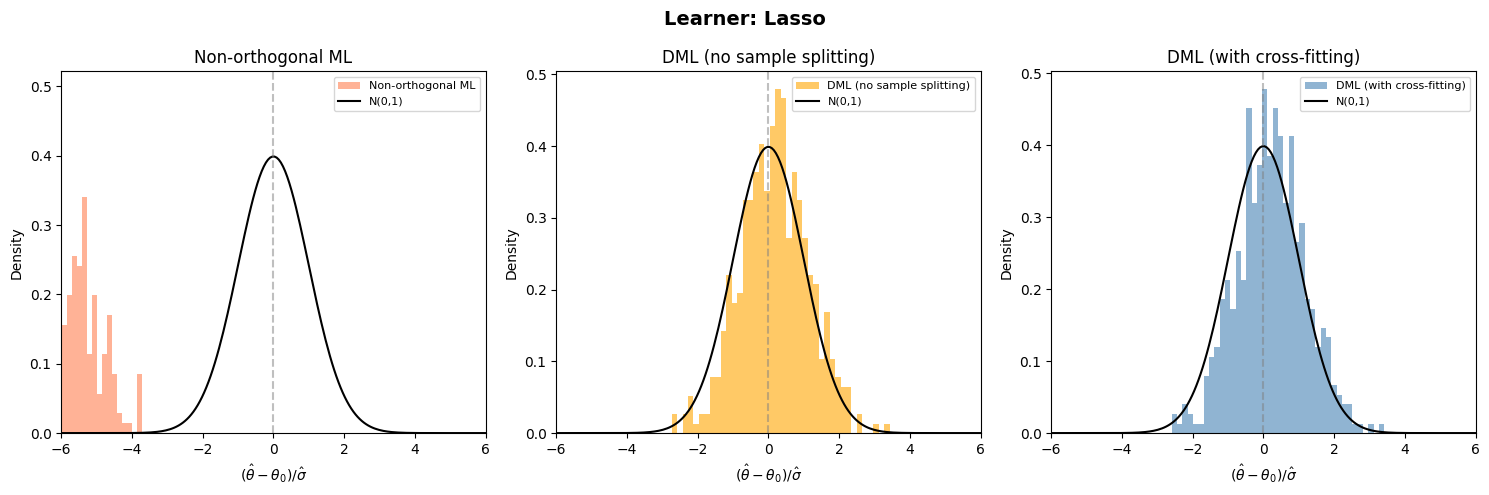

[ElasticNet] Replication 0/500...
[ElasticNet] Replication 100/500...
[ElasticNet] Replication 200/500...
[ElasticNet] Replication 300/500...
[ElasticNet] Replication 400/500...
[ElasticNet] Valid reps: 500/500


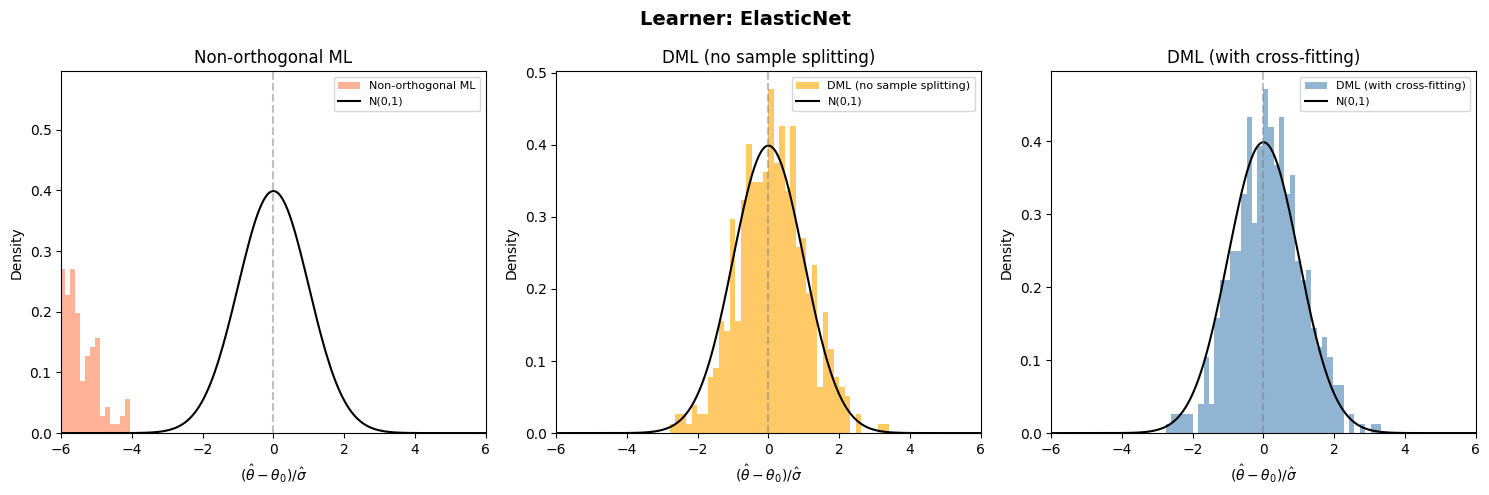

In [15]:
from experiments.exp1_estimator_comparison import run_experiment_1, plot_experiment_1
from dml.learners.lasso import LassoLearner
from dml.learners.elastic_net import ElasticNetLearner

# Lasso
results_lasso = run_experiment_1('Lasso', LassoLearner, n_obs=500, n_reps=500)
plot_experiment_1(results_lasso, 'Lasso',
                  save_path='../results/exp1_lasso.png')

# ElasticNet
results_en = run_experiment_1('ElasticNet', ElasticNetLearner, n_obs=500, n_reps=500)
plot_experiment_1(results_en, 'ElasticNet',
                  save_path='../results/exp1_elasticnet.png')

In [ ]:
from experiments.exp1_estimator_comparison import run_experiment_1, plot_experiment_1
from dml.learners.random_forest import RandomForestLearner

results_rf = run_experiment_1('RandomForest', RandomForestLearner, n_obs=500, n_reps=500)
plot_experiment_1(results_rf, 'RandomForest',
                  save_path='../results/exp1_rf.png')

[RandomForest] Replication 0/500...


[NeuralNet] Replication 0/500...
[NeuralNet] Replication 100/500...
[NeuralNet] Replication 200/500...
[NeuralNet] Replication 300/500...
[NeuralNet] Replication 400/500...
[NeuralNet] Valid reps: 500/500


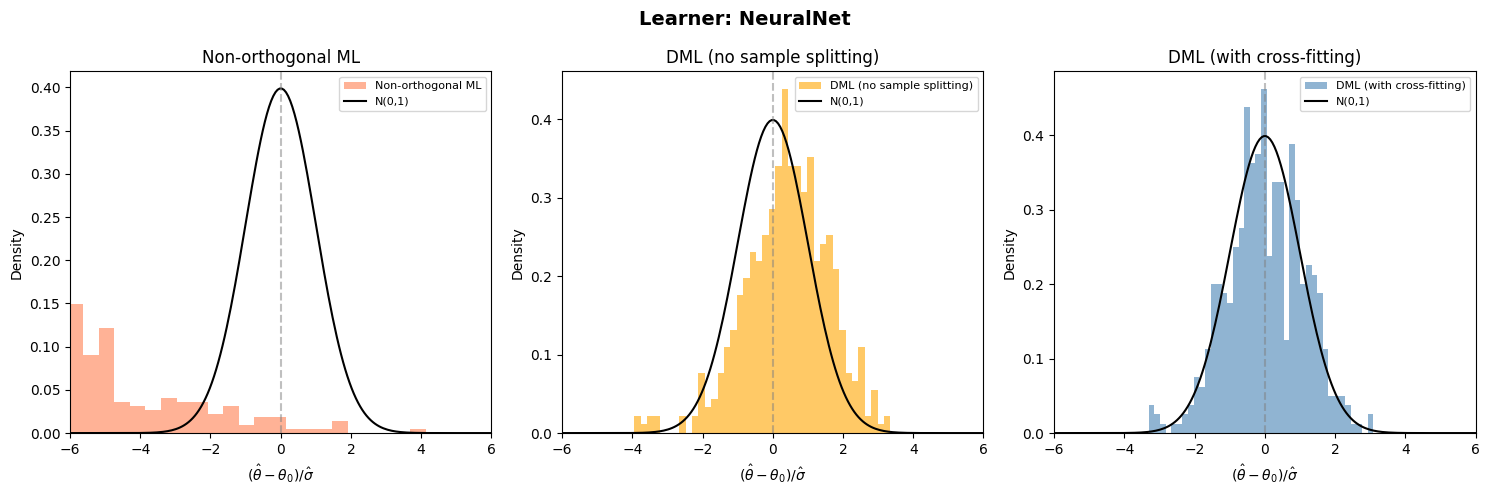

In [ ]:
from dml.learners.neural_net import NeuralNetLearner

results_nn = run_experiment_1('NeuralNet', NeuralNetLearner, n_obs=500, n_reps=500)
plot_experiment_1(results_nn, 'NeuralNet',
                  save_path='../results/exp1_nn.png')

[CausalForest] Replication 0/500...
[CausalForest] Replication 100/500...
[CausalForest] Replication 200/500...
[CausalForest] Replication 300/500...
[CausalForest] Replication 400/500...
[CausalForest] Valid reps: 500/500


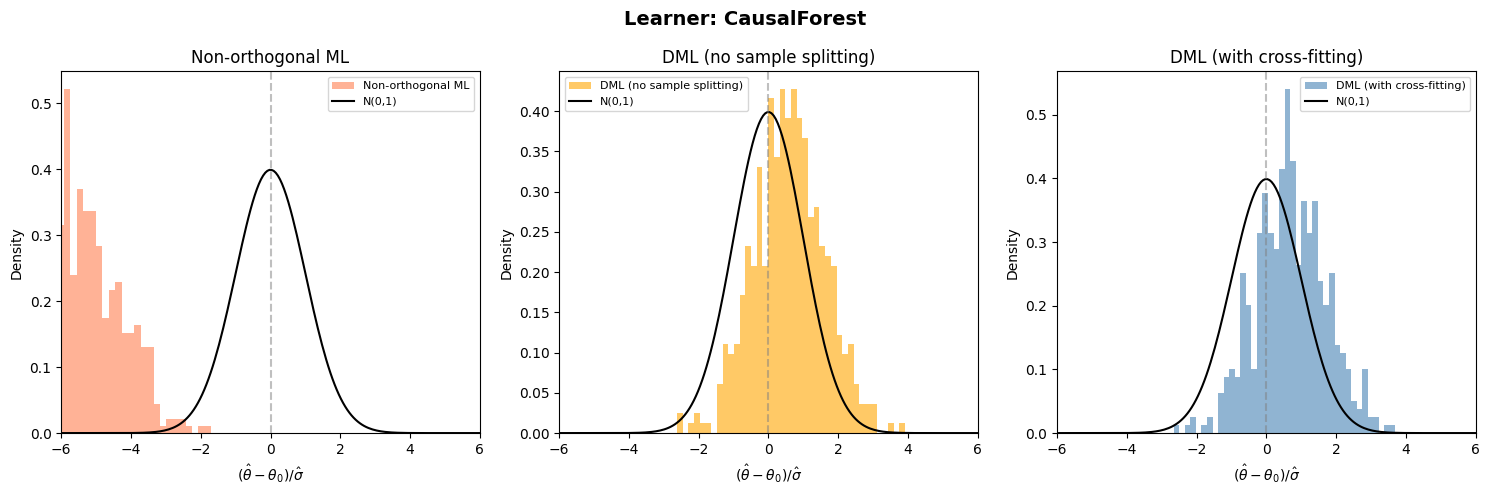

In [ ]:
from dml.learners.causal_forest import CausalForestLearner

results_cf = run_experiment_1('CausalForest', CausalForestLearner, n_obs=500, n_reps=500)
plot_experiment_1(results_cf, 'CausalForest',
                  save_path='../results/exp1_cf.png')

## 15. Experiment 2 — Learner Comparison
Five learners × n ∈ {200, 500, 1000, 2000}, 500 reps each.
Metrics: bias, RMSE, CI coverage rate.

In [ ]:
from experiments.exp2_learner_comparison import run_experiment_2, plot_experiment_2
from dml.learners.lasso import LassoLearner
from dml.learners.elastic_net import ElasticNetLearner

# 先只测试 Lasso，n_reps=10，确认没有报错
from experiments.exp2_learner_comparison import LEARNERS, N_VALUES, run_single_rep
import numpy as np

# 快速测试
for rep in range(3):
    res = run_single_rep(LassoLearner, 200, 0.5, random_state=rep)
    print(res)

{'theta': np.float64(0.4789224990026494), 'se': np.float64(0.060750463848011964), 'covered': np.True_, 'bias': np.float64(-0.021077500997350618), 'rmse': np.float64(0.0004442610482933163)}
{'theta': np.float64(0.5470228411352837), 'se': np.float64(0.07564806075714013), 'covered': np.True_, 'bias': np.float64(0.047022841135283655), 'rmse': np.float64(0.0022111475884341245)}
{'theta': np.float64(0.5669636904145339), 'se': np.float64(0.06121361182827456), 'covered': np.True_, 'bias': np.float64(0.06696369041453387), 'rmse': np.float64(0.004484135833933535)}


In [ ]:
df_exp2 = run_experiment_2(n_reps=50)
print(df_exp2)
plot_experiment_2(df_exp2,
                  save_path='../results/exp2_learner_comparison.png')

[Lasso] n=200...
  bias=0.0149, rmse=0.0716, coverage=0.940
[Lasso] n=500...
  bias=0.0163, rmse=0.0466, coverage=0.920
[Lasso] n=1000...
  bias=0.0079, rmse=0.0264, coverage=0.940
[Lasso] n=2000...
  bias=0.0076, rmse=0.0226, coverage=0.940
[ElasticNet] n=200...
  bias=0.0119, rmse=0.0733, coverage=0.900
[ElasticNet] n=500...
  bias=0.0130, rmse=0.0454, coverage=0.940
[ElasticNet] n=1000...
  bias=0.0049, rmse=0.0257, coverage=0.960
[ElasticNet] n=2000...
  bias=0.0047, rmse=0.0218, coverage=0.940
[RandomForest] n=200...
  bias=-0.0104, rmse=0.0688, coverage=0.960
[RandomForest] n=500...
  bias=-0.0047, rmse=0.0425, coverage=0.960
[RandomForest] n=1000...
  bias=-0.0123, rmse=0.0307, coverage=0.960
[RandomForest] n=2000...


[Lasso] n=200...
  bias=0.0047, rmse=0.0727, coverage=0.936
[Lasso] n=500...
  bias=0.0093, rmse=0.0439, coverage=0.950
[Lasso] n=1000...
  bias=0.0072, rmse=0.0324, coverage=0.926
[Lasso] n=2000...
  bias=0.0057, rmse=0.0243, coverage=0.922
[ElasticNet] n=200...
  bias=0.0020, rmse=0.0734, coverage=0.932
[ElasticNet] n=500...
  bias=0.0063, rmse=0.0435, coverage=0.952
[ElasticNet] n=1000...
  bias=0.0043, rmse=0.0320, coverage=0.940
[ElasticNet] n=2000...
  bias=0.0027, rmse=0.0238, coverage=0.926
[RandomForest] n=200...
  bias=-0.0125, rmse=0.0741, coverage=0.930
[RandomForest] n=500...
  bias=-0.0108, rmse=0.0480, coverage=0.936
[RandomForest] n=1000...
  bias=-0.0118, rmse=0.0343, coverage=0.934
[RandomForest] n=2000...
  bias=-0.0126, rmse=0.0287, coverage=0.860
[NeuralNet] n=200...
  bias=0.0058, rmse=0.0746, coverage=0.924
[NeuralNet] n=500...
  bias=0.0011, rmse=0.0473, coverage=0.942
[NeuralNet] n=1000...
  bias=-0.0015, rmse=0.0337, coverage=0.932
[NeuralNet] n=2000...
  bias

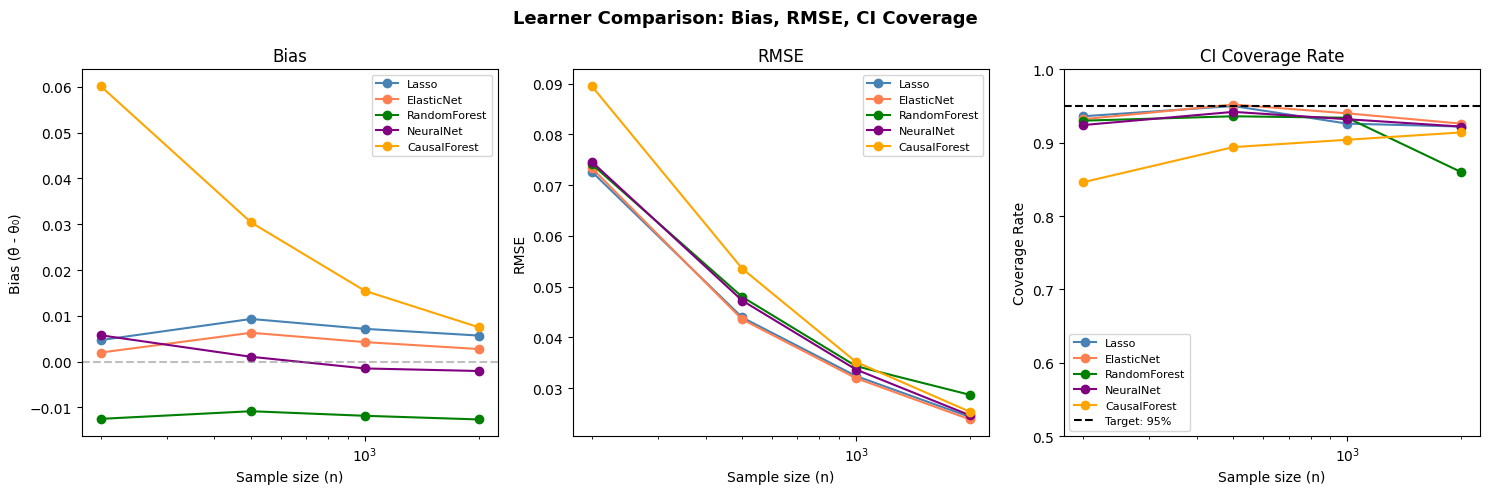

In [ ]:
from experiments.exp2_learner_comparison import run_experiment_2, plot_experiment_2

df_exp2 = run_experiment_2(n_reps=500)
print(df_exp2)
plot_experiment_2(df_exp2,
                  save_path='../results/exp2_learner_comparison.png')